In [1]:
import pathlib

import pandas as pd

In [2]:
# ID MAP
id_map = [
    {"leaf": "Alanine", "ch": "Carbon-L-Alanine", "pmi": "L-Alanine"},
    {"leaf": "Arginine", "ch": "Carbon-L-Arginine", "pmi": "L-Arginine"},
    {"leaf": "Cellobiose", "ch": "Carbon-D-Cellobiose", "pmi": "D-Cellobiose"},
    {"leaf": "Fructose", "ch": "Carbon-D-Fructose", "pmi": "D-Fructose"},
    {"leaf": "Galactose", "ch": "Carbon-D-Galactose", "pmi": "D-Galactose"},
    {"leaf": "Glucose", "ch": "Carbon-D-Glucose", "pmi": "a-D-Glucose"},
    {"leaf": "Glycerol", "ch": "Carbon-Glycerol", "pmi": "Glycerol"},
    {"leaf": "Histidine", "ch": "Carbon-L-Histidine", "pmi": "L-Histidine"},
    {"leaf": "Maltose", "ch": "Carbon-Maltose", "pmi": "Maltose"},
    {"leaf": "Mannitol", "ch": "Carbon-D-Mannitol", "pmi": "D-Mannitol"},
    {"leaf": "Mannose", "ch": "Carbon-D-Mannose", "pmi": "D-Mannose"},
    {"leaf": "Serine", "ch": "Carbon-D-Serine", "pmi": "D-Serine"},
    {"leaf": "Serine", "ch": "Carbon-L-Serine", "pmi": "L-Serine"},
    {"leaf": "Sucrose", "ch": "Carbon-Sucrose", "pmi": "Sucrose"},
    {"leaf": "Trehalose", "ch": "Carbon-D-Trehalose", "pmi": "D-Trehalose"},
]

## Create the training feature matrix

In [3]:
combined_features_folder = pathlib.Path("../../data/processed/biolog/features_combined")
ch_combined_folder = combined_features_folder / "ch"
leaf_combined_folder = combined_features_folder / "leaf"

In [8]:
reduced_features_folder = pathlib.Path("../../data/processed/biolog/features_reduced")
reduced_features_folder.is_dir()

True

In [4]:
from trait_prediction.utils import read_generic_features

In [28]:
train_features = dict()
for map in id_map:
    leaf_file = leaf_combined_folder / f"{map['leaf']}_features_combined.tsv"
    leaf_features = read_generic_features(leaf_file, bool_conversion=True, dtype="uint8")
    ch_file = ch_combined_folder / f"{map['ch']}_features_combined.tsv"
    ch_features = read_generic_features(ch_file, bool_conversion=True, dtype="uint8")
    combined_features = pd.concat([leaf_features, ch_features], axis=0).fillna(0).astype("uint8")
    train_features[map["ch"]] = combined_features

train_features["Carbon-D-Glucose"]

,1282_5979,1392_5622,991_672,35_380,934_6222,1282_2688,743_2344,1232_670,414_6332,390_752,...,UniRef30_A0A2P6AVJ3,UniRef30_B3PJB5,UniRef30_A0A2D7WE87,UniRef30_A0A836TRE3,UniRef30_N9BAC4,UniRef30_A0A385C8D2,UniRef30_A0A1D8IK45,UniRef30_A0A5J6PXQ2,UniRef30_A0A3D1BAC6,UniRef30_A0A977Z6M3
genomeID,,,,,,,,,,,,,,,,,,,,,
GCF_001421155.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421165.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421245.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421275.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421285.1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134536.48,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
693973.6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
754262.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [25]:
def get_pmi_features(pmi_files, feature_cols):
    pmi_feature_df_list = []
    for pmi_file in pmi_files:
        if pmi_file.parent.name in ["kofam_modules", "uniprot_trembl"]:
            continue
        feature_df = read_generic_features(pmi_file, bool_conversion=True, dtype="uint8")
        common_cols = feature_df.columns.intersection(feature_cols)
        pmi_feature_df_list.append(feature_df.loc[:, common_cols]) # type: ignore
    pmi_features = pd.concat(pmi_feature_df_list, axis=1).fillna(0).astype("uint8")
    pmi_features = pmi_features.loc[:, ~pmi_features.columns.duplicated()].copy() # type: ignore
    missing_cols = list(set(feature_cols) - set(pmi_features.columns))
    pmi_features.loc[:, missing_cols] = 0
    return pmi_features.loc[:, feature_cols].copy()

In [26]:
from tqdm import tqdm

In [27]:
test_features = dict()
pmi_files = list(reduced_features_folder.glob("**/*_pmi_features_reduced.tsv"))
for map in tqdm(id_map):
    train_X = train_features[map["ch"]]
    feature_cols = list(train_X.columns)
    pmi_features = get_pmi_features(pmi_files, feature_cols)
    test_features[map["ch"]] = pmi_features

test_features["Carbon-D-Glucose"]

100%|██████████| 15/15 [00:33<00:00,  2.21s/it]


,1282_5979,1392_5622,991_672,35_380,934_6222,1282_2688,743_2344,1232_670,414_6332,390_752,...,UniRef30_A0A2P6AVJ3,UniRef30_B3PJB5,UniRef30_A0A2D7WE87,UniRef30_A0A836TRE3,UniRef30_N9BAC4,UniRef30_A0A385C8D2,UniRef30_A0A1D8IK45,UniRef30_A0A5J6PXQ2,UniRef30_A0A3D1BAC6,UniRef30_A0A977Z6M3
genomeID,,,,,,,,,,,,,,,,,,,,,
Bacillus_sp._BC15_2615840537,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Variovorax_sp._CF313_2513020051,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Duganella_sp._CF402_2616644845,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Pantoea_sp._YR343_2511231025,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Burkholderia_sp._BT03_2711768613,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rhizobium_sp._AP16_2510917022,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rhizobium_sp._CF394_2582581294,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rhizobium_sp._CF097_2582581866,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Rhizobium_sp._CF122_2510917028,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Create target matrices

In [29]:
phenotype_folder = pathlib.Path("../../data/processed/biolog/phenotypes")
ch_phenotype_file = phenotype_folder / "ch_phenotypes.tsv"
leaf_phenotype_file = phenotype_folder / "leaf_phenotypes.tsv"
pmi_phenotype_file = phenotype_folder / "pmi_phenotypes.tsv"
ch_phenotype_file.is_file(), leaf_phenotype_file.is_file(), pmi_phenotype_file.is_file()

(True, True, True)

In [32]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex

In [34]:
train_y = dict()
test_y = dict()
for map in id_map:
    ch_phenotype = PhenotypeSet.read_data(ch_phenotype_file)
    leaf_phenotype = PhenotypeSet.read_data(leaf_phenotype_file)
    pmi_phenotype = PhenotypeSet.read_data(pmi_phenotype_file)
    ch_index = PhenotypeIndex(map["ch"], "ch_biolog")
    leaf_index = PhenotypeIndex(map["leaf"], "leaf_biolog")
    pmi_index = PhenotypeIndex(map["pmi"], "pmi_biolog")
    train_y[map["ch"]] = pd.concat([ch_phenotype[ch_index].phenotype_data, leaf_phenotype[leaf_index].phenotype_data], axis=0)
    test_y[map["ch"]] = pmi_phenotype[pmi_index].phenotype_data

In [35]:
train_y["Carbon-D-Glucose"]

genomeID
149698.22          1
702115.9           1
1663.218           1
242605.18          1
134536.40          1
                  ..
GCF_920984695.1    1
GCF_920984705.1    0
GCF_920984725.1    1
GCF_920984735.1    1
GCF_942548115.1    1
Length: 529, dtype: uint8

In [36]:
test_y["Carbon-D-Glucose"]

genomeID
Bacillus_sp._BC15_2615840537.fna                 1
Variovorax_sp._CF313_2513020051.fna              1
Duganella_sp._CF402_2616644845.fna               1
Pantoea_sp._YR343_2511231025.fna                 1
Burkholderia_sp._BT03_2711768613.fna             1
Rhizobium_sp._AP16_2510917022.fna                1
Rhizobium_sp._CF394_2582581294.fna               1
Rhizobium_sp._CF097_2582581866.fna               1
Rhizobium_sp._CF122_2510917028.fna               1
Rhizobium_sp._CF142_2510917030.fna               1
Rhizobium_sp._CF258_2582581865.fna               1
Rhizobium_sp._OK665_2582581283.fna               1
Rhizobium_sp._OV201_2582581867.fna               1
Rhizobium_leguminosarum_OV483_2582581299.fna     1
Rhizobium_sp._YR295_2582581306.fna               1
Rhizobium_sp._CF048_2585427590.fna               1
Rhizobium_sp._CF080_2562617114.fna               1
Agrobacterium_rhizogenes_CF262_2585428125.fna    1
Agrobacterium_rhizogenes_CF263_2585427609.fna    1
Rhizobium_leguminosaru

## ML

In [37]:

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
def make_classifier(random_state: int, categorical_feature_names: list[str] | None):
    """
    Creates a classifier.

    Parameters
    ---------
    random_state : int
        Random state.
    categorical_feature_names : list[str] | None
        List of categorical feature names.

    Returns
    ------
    Classifier object.
    """
    clf = CatBoostClassifier(
        # iterations=1000,
        # depth=8,
        # learning_rate=0.03,
        # l2_leaf_reg=3,
        # bootstrap_type="Bayesian",
        # bagging_temperature=1,
        random_state=random_state,
        objective="Logloss",
        cat_features=categorical_feature_names,
        verbose=False,
        allow_writing_files=False,
        thread_count=1,
    )
    return clf


def get_scores(
    y_true: pd.Series, y_pred: pd.Series, name, category,
) -> pd.DataFrame:
    """
    Calculates the scores for the given true and predicted labels.

    Parameters
    ---------
    y_true : pd.DataFrame
        True labels.
    y_pred : pd.DataFrame
        Predicted labels.

    Returns
    ------
    pd.DataFrame
        Scores.
    """
    scores = {
        "name": name,
        "category": category,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "matthews_corrcoef": matthews_corrcoef(y_true, y_pred),
    }
    index = f"{name}-{category}"
    return pd.DataFrame(scores, index=[index])

In [40]:
scores = []
for map in id_map:
    y = train_y[map["ch"]]
    X = train_features[map["ch"]]
    common_index = X.index.intersection(y.index)
    y = y.loc[common_index]
    X = X.loc[common_index]
    clf = make_classifier(42, list(X.columns))
    clf.fit(X, y)
    y_pred = clf.predict(test_features[map["ch"]])
    scores.append(get_scores(test_y[map["ch"]], y_pred, map["ch"], "biolog"))

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [42]:
scores_df = pd.concat(scores)
scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
Carbon-L-Alanine-biolog,Carbon-L-Alanine,biolog,0.672727,0.500000,0.804348,0.672727,1.000000,0.000000
Carbon-L-Arginine-biolog,Carbon-L-Arginine,biolog,0.709091,0.578947,0.818182,0.692308,1.000000,0.330623
Carbon-D-Cellobiose-biolog,Carbon-D-Cellobiose,biolog,0.890909,0.886605,0.903226,0.848485,0.965517,0.787979
Carbon-D-Fructose-biolog,Carbon-D-Fructose,biolog,0.890909,0.500000,0.942308,0.890909,1.000000,0.000000
Carbon-D-Galactose-biolog,Carbon-D-Galactose,biolog,0.890909,0.571429,0.941176,0.888889,1.000000,0.356348
Carbon-D-Glucose-biolog,Carbon-D-Glucose,biolog,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
Carbon-Glycerol-biolog,Carbon-Glycerol,biolog,0.890909,0.490000,0.942308,0.907407,0.980000,-0.043033
Carbon-L-Histidine-biolog,Carbon-L-Histidine,biolog,0.763636,0.593750,0.857143,0.750000,1.000000,0.375000
Carbon-Maltose-biolog,Carbon-Maltose,biolog,0.945455,0.942204,0.952381,0.937500,0.967742,0.889202
Carbon-D-Mannitol-biolog,Carbon-D-Mannitol,biolog,0.963636,0.823718,0.980769,0.980769,0.980769,0.647436


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

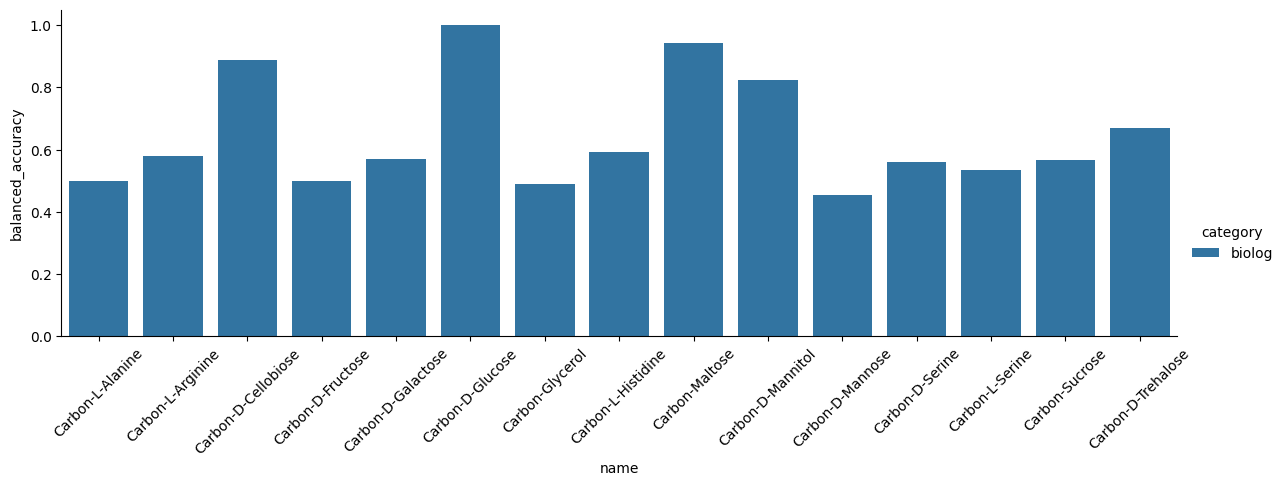

In [48]:
sns.catplot(data=scores_df, kind="bar", aspect=3, height=4, x="name", y="balanced_accuracy", hue="category")
plt.tick_params(axis="x", rotation=45)